### Test the ccg NOAA curve filtering package

In [11]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

C:\Users\leob\AppData\Local\Temp\ipykernel_14220\1823364867.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [5]:
import ccg_filter as ccgfilt

C:\Users\leob\AppData\Local\Temp\ipykernel_14220\595772677.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv("../mlotestdata.txt", header=None, sep="  ")


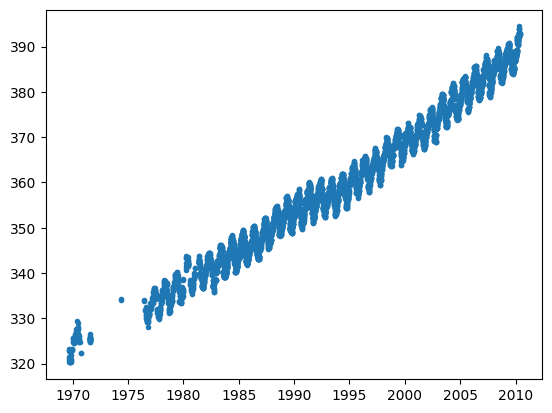

In [67]:
## Run it with test data
# read test data
df = pd.read_csv("../mlotestdata.txt", header=None, sep="  ")
# df = df.drop([0, 2], axis=1)

xp = df.iloc[:, 0]
yp = df.iloc[:, 1]
df

plt.plot(xp, yp, ls="", marker=".")

In [81]:
# create the ccgfilt object
# Note:  For less than 3 years of data it is best 
# to use a linear term for the polynomial part of the function (k=2)

filt = ccgfilt.ccgFilter(
    xp,
    yp,  # shortterm, longterm, sampleinterval,
    numpolyterms=3,  # number of polynomial terms, 3 = quadratic
    # numharmonics, timezero, gap, debug
)
#
mm = filt.getMonthlyMeans()
amps = filt.getAmplitudes()
tcup, tcdown = filt.getTrendCrossingDates()

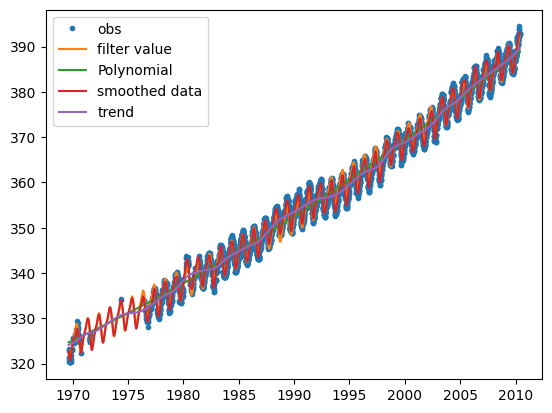

In [82]:
# get x,y data for plotting
x0 = filt.xinterp
y1 = filt.getFunctionValue(x0)
y2 = filt.getPolyValue(x0)
y3 = filt.getSmoothValue(x0)
y4 = filt.getTrendValue(x0)

plt.figure()
plt.plot(xp, yp, ls="", marker=".", label="obs")
plt.plot(x0, y1, label="filter value")
plt.plot(x0, y2, label="Polynomial")
plt.plot(x0, y3, label="smoothed data")  # = function fit + filtered residuals
plt.plot(x0, y4, label="trend")  # trend with seasonal cycle removed
plt.legend()
# plt.xlim([2000, 2005])
# plt.ylim([360, 380])

In [72]:
y2

array([324.67964935, 324.70795944, 324.73628243, ..., 388.9290441 ,
       388.97862495, 389.00674934])

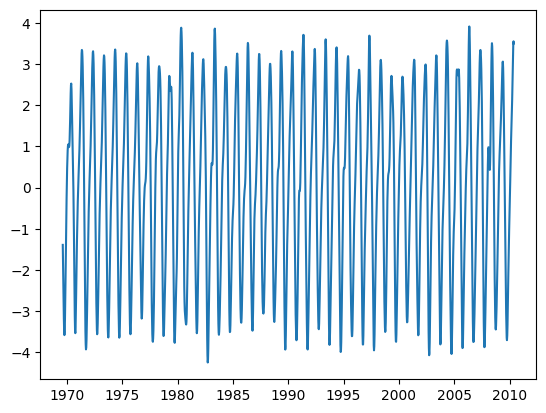

In [64]:
# Seasonal Cycle
# x and y are original data points
trend = filt.getTrendValue(xp)
detrend = yp - trend
harmonics = filt.getHarmonicValue(x0)
smooth_cycle = harmonics + filt.smooth - filt.trend

plt.plot(x0, smooth_cycle)

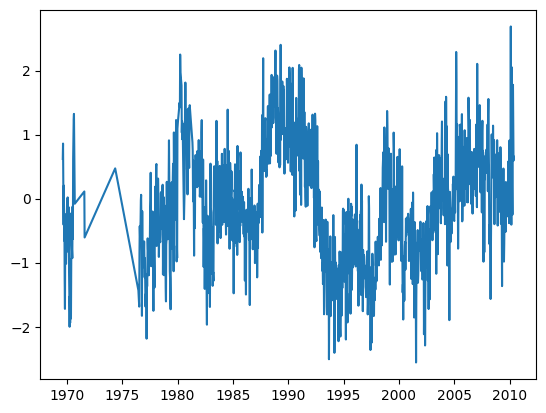

In [66]:
# residuals from the function
resid_from_func = filt.resid

# smoothed residuals
resid_smooth = filt.smooth

# trend of residuals
resid_trend = filt.trend

# residuals about the smoothed line
resid_from_smooth = filt.yp - filt.getSmoothValue(xp)

# equally spaced interpolated data with function removed
x1 = filt.xinterp
y9 = filt.yinterp

plt.figure()
plt.plot(x1, y9)